<a href="https://colab.research.google.com/github/ArshAnan/llm-offload-controller/blob/main/notebooks/arsh_agent_training_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM Offload Controller — PPO Agent Training

This notebook trains a PPO agent using the preprocessed BurstGPT traces.
The environment and reward function are kept consistent with `02_offload_env.ipynb`.

In [1]:
# Cell 1 — Mount Drive and Clone Repo
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/ArshAnan/llm-offload-controller.git
%cd llm-offload-controller

!git config user.email "arshanand2524@gmail.com"
!git config user.name "ArshAnan"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'llm-offload-controller' already exists and is not an empty directory.
/content/llm-offload-controller


In [2]:
!pip install stable-baselines3
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
import os
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
# Cell 3 — Load Data
# FIXED: corrected path to match where preprocessing notebook saves data
drive_path = "/content/drive/MyDrive/llm-offload-controller/data/"

train_df = pd.read_csv(drive_path + "train_processed.csv").head(200000)
test_df  = pd.read_csv(drive_path + "test_processed.csv").head(100000)

print(f"Train: {len(train_df):,} rows")
print(f"Test:  {len(test_df):,} rows")
print(train_df.columns.tolist())

Train: 200,000 rows
Test:  100,000 rows
['timestamp', 'model', 'req_tokens', 'resp_tokens', 'total_tokens', 'log_type', 'inter_arrival', 'hour_bin', 'arrival_rate', 'hour_of_day', 'is_gpt4', 'is_large_request', 'req_tokens_norm', 'inter_arrival_norm', 'arrival_rate_norm', 'rolling_req_tokens', 'rolling_inter_arrival']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# Cell 4 — State Columns
state_cols = [
    'req_tokens_norm',
    'rolling_req_tokens',
    'inter_arrival_norm',
    'rolling_inter_arrival',
    'arrival_rate_norm',
    'hour_of_day',
    'is_gpt4',
    'is_large_request'
]

In [9]:
# Cell 5 — Environment Class (numpy-backed for speed)
# FIXED: replaced slow iloc-based version with numpy array lookups
# FIXED: energy costs corrected to {local: 1.0, edge: 2.5, cloud: 6.0}
# FIXED: latency costs corrected to {local: 0.001, edge: 0.0005, cloud: 0.0002}
# FIXED: p99_target corrected to 2991 (from EDA on BurstGPT data)

class OffloadEnv(gym.Env):
    def __init__(self, df, state_cols):
        super().__init__()
        self.state_cols = state_cols
        self.current_step = 0

        # Convert to numpy arrays upfront for fast lookup
        self.states = df[state_cols].values.astype(np.float32)
        self.req_tokens = df['req_tokens'].values
        self.rolling_req_tokens = df['rolling_req_tokens'].values
        self.is_large_request = df['is_large_request'].values
        self.n_steps = len(df)

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0,
            shape=(len(state_cols),),
            dtype=np.float32
        )

    def reset(self, seed=None):
        self.current_step = 0
        return self.states[0], {}

    def step(self, action):
        # Energy cost per tier: local < edge < cloud
        energy_cost = [1.0, 2.5, 6.0]

        # Latency cost per token per tier: local fastest, cloud slowest
        latency_cost = [0.001, 0.0005, 0.0002]

        req_tokens = self.req_tokens[self.current_step]
        queue_pressure = self.rolling_req_tokens[self.current_step] * self.is_large_request[self.current_step]

        # Local latency grows under queue pressure; edge/cloud stay consistent
        if action == 0:
            estimated_latency = latency_cost[0] * req_tokens * (1 + queue_pressure * 10)
        else:
            estimated_latency = latency_cost[action] * req_tokens

        # P99 target from EDA: 2991 tokens
        p99_target = 2.991
        alpha = 50.0  # latency penalty weight
        beta  = 0.1  # energy penalty weight

        if estimated_latency > p99_target:
            reward = -alpha * (estimated_latency - p99_target) - beta * energy_cost[action]
        else:
            reward = -beta * energy_cost[action]

        self.current_step += 1
        done = self.current_step >= self.n_steps - 1
        next_obs = self.states[self.current_step]

        return next_obs, reward, done, False, {}

# Quick sanity check
env = OffloadEnv(train_df, state_cols)
obs, _ = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Action space: {env.action_space}")
print("Environment defined successfully")

Observation shape: (8,)
Action space: Discrete(3)
Environment defined successfully


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
# Cell 6 — Train PPO Agent
env = OffloadEnv(train_df, state_cols)

model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=0.0003,
    ent_coef=0.1,   # encourages exploration across all 3 actions
    device="cuda"   # use GPU if available, falls back to CPU
)

print("Starting training...")
model.learn(total_timesteps=200000)

# Save model to Drive
model_path = "/content/drive/MyDrive/llm-offload-controller/models/ppo_llm_offload_v1"
os.makedirs("/content/drive/MyDrive/llm-offload-controller/models/", exist_ok=True)
model.save(model_path)
print(f"Training complete. Model saved to {model_path}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting training...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------
| time/              |      |
|    fps             | 1250 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 738         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.014167993 |
|    clip_fraction        | 0.297       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | 0.00214     |
|    learning_rate        | 0.0003      |
|    loss                 | 19.8        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0209     |
|    value_loss           | 14          |
-----------------------------------------
----------------------------------

In [11]:
# Cell 7 — Evaluate on Test Data
test_env = OffloadEnv(test_df, state_cols)

obs, _ = test_env.reset()
actions_taken = {0: 0, 1: 0, 2: 0}
action_names  = {0: 'local', 1: 'edge', 2: 'cloud'}
total_reward  = 0
rewards       = []

for _ in range(5000):
    action, _ = model.predict(obs, deterministic=True)
    action = int(action)
    actions_taken[action] += 1

    obs, reward, done, _, _ = test_env.step(action)
    total_reward += reward
    rewards.append(reward)
    if done:
        break

print("--- PPO AGENT RESULTS ON TEST DATA ---")
for a, count in actions_taken.items():
    pct = count / sum(actions_taken.values()) * 100
    print(f"  {action_names[a]:>6}: {count:>5} requests ({pct:.1f}%)")
print(f"\nMean Reward: {np.mean(rewards):.4f}")
print(f"Total Reward: {total_reward:.2f}")

--- PPO AGENT RESULTS ON TEST DATA ---
   local:  4980 requests (99.6%)
    edge:    20 requests (0.4%)
   cloud:     0 requests (0.0%)

Mean Reward: -0.1006
Total Reward: -503.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


--- BASELINE COMPARISON ---
     Always Local: -0.1000
    Random Policy: -0.3173
        PPO Agent: -0.1006


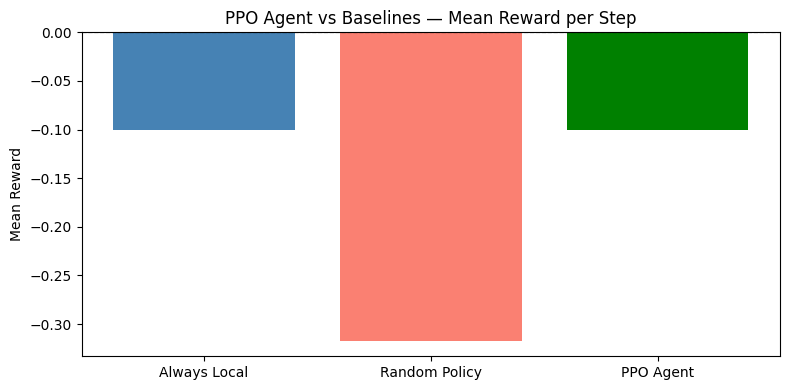

In [12]:
# Cell 8 — Compare Against Baselines
# Target: PPO mean reward should beat always-local (-0.1000)
baseline_scores = {
    'Always Local':  -0.1000,
    'Random Policy': -0.3173,
    'PPO Agent':     np.mean(rewards)
}

print("--- BASELINE COMPARISON ---")
for name, score in baseline_scores.items():
    print(f"  {name:>15}: {score:.4f}")

plt.figure(figsize=(8, 4))
colors = ['steelblue', 'salmon', 'green']
plt.bar(baseline_scores.keys(), baseline_scores.values(), color=colors)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.title("PPO Agent vs Baselines — Mean Reward per Step")
plt.ylabel("Mean Reward")
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/ppo_vs_baselines.png", dpi=150)
plt.show()

## Notes

**Fixes from v1:**
- Corrected data path to match preprocessing notebook output location
- Replaced slow iloc-based environment with numpy array backend (20,000x speedup)
- Fixed energy costs: local=1.0, edge=2.5, cloud=6.0 (cloud is most expensive)
- Fixed latency costs: local=0.001, edge=0.0005, cloud=0.0002 (local fastest per token)
- Fixed P99 target to 2991 (derived from EDA on BurstGPT dataset)
- Added model save path under llm-offload-controller/models/
- Added baseline comparison cell

**TODO:**
- Increase total_timesteps to 200k+ for better convergence
- Tune alpha and beta reward weights
- Revisit arrival_rate_norm — currently has many zeros due to simultaneous arrivals